# A/A Testing: False Positive Rate & the Optional Stopping Problem

## What this notebook is about

This notebook uses Monte Carlo simulation to study two questions that are central to the validity of A/B experiments:

1. **Is our test well-calibrated?** In an A/A test (true effect = 0), a correctly calibrated test at significance level α should flag roughly α × 100% of experiments as "significant". We verify this holds.

2. **What happens when we let borderline results run longer?** A common real-world behaviour is *optional stopping*: an experimenter sees a "trending" result (the CI looks promising but doesn't yet exclude zero) and decides to collect more data. We quantify exactly how much this inflates the false positive rate.

---

### Experimental setup

| Parameter | Value |
|-----------|-------|
| Metric | Binary conversion (Bernoulli) |
| Baseline conversion rate | 5% |
| Users per experiment | 100,000 (50k per arm) |
| Significance threshold (α) | 10% (two-sided) |
| Confidence interval | 90% two-sided |
| Number of simulated experiments | 1,000 |

> **A/A test**: both variants receive identical treatment — the true effect is exactly **0%**. Every "significant" result is therefore a *false positive* (Type I error).

In [1]:
from IPython.display import display, HTML, Image
display(HTML("<style>.container { width:100% !important; }</style>"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from tqdm import tqdm

from scipy.stats import chi2_contingency, chi2, ttest_ind_from_stats, norm, binom, mannwhitneyu, t, chisquare
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint

from datetime import datetime
pd.set_option('display.max_colwidth', None)

from exp_tools.stat_tools import *

import plotly.offline as pyo
import plotly.io as pio
pio.renderers.default = 'iframe'

In [2]:
def vertical_plot_lines(x, xal, yal, **kwargs):
    plt.axvline(x.mean(), linestyle='--', color=kwargs.get("color", "g"), alpha=0.5)
    tx_mean = "mean: {:.1%}".format(x.mean())
    txkw = dict(size=11, color=kwargs.get("color", "g"), rotation=90)
    plt.text(x.mean() + xal, yal, tx_mean, **txkw)


def draw_heatmap(data, row_var, col_var, value_var, **kwargs):
    data_pivot = data.pivot(index=row_var, columns=col_var, values=value_var)
    sns.heatmap(data_pivot, **kwargs)


def annotate_mean(data, metric, **kwargs):
    tx_mean = f"% Sig. results:{data[metric].mean():.0%}"
    plt.text(3.5, 9.5, tx_mean, dict(size=12))

In [3]:
def get_results(data, metric_field, confidence=0.9, threshold=None, calculate_ratio=True, **kwargs):
    """Silent version that returns a result dict instead of printing."""
    df_stats = get_df_stats(data, metric_field)
    stats = get_stats(df_stats, non_inferiority_threshold=threshold)

    if threshold is not None:
        confidence = 1 - (1 - confidence) * 2

    if kwargs.get('mannwhitney'):
        get_mann_whitney_test(data, metric_field, confidence)

    plot_arg = kwargs.get('plot', False)

    estimate, ci_l, ci_h = get_ci(
        df_stats,
        metric_field,
        confidence=confidence,
        plot=plot_arg,
        non_inferiority_threshold=threshold,
        ratio=calculate_ratio
    )

    return {
        'estimate': estimate,
        'ci_l': ci_l,
        'ci_h': ci_h,
        'p-value': stats['p-value']
    }


def get_ci(df_stats, metric_field, confidence=0.9, plot=True, non_inferiority_threshold=None, ratio=True):
    """Silent version that returns (estimate, ci_l, ci_h)."""
    if df_stats['binary'].all():
        estimate, ci_l, ci_h = improv_interval_binomial(
            confidence=confidence,
            successes_base=df_stats.at[0, 'reached_goal'],
            successes_var=df_stats.at[1, 'reached_goal'],
            obs_base=df_stats.at[0, 'visitors'],
            obs_var=df_stats.at[1, 'visitors']
        )
    else:
        if ratio:
            estimate, ci_l, ci_h = confidence_interval_ratio(
                confidence=confidence,
                avg_base=df_stats.at[0, 'reached_goal'] / df_stats.at[0, 'visitors'],
                avg_var=df_stats.at[1, 'reached_goal'] / df_stats.at[1, 'visitors'],
                stdev_base=df_stats.at[0, 'stdv'],
                stdev_var=df_stats.at[1, 'stdv'],
                obs_base=df_stats.at[0, 'visitors'],
                obs_var=df_stats.at[1, 'visitors']
            )
        else:
            estimate, ci_l, ci_h = confidence_interval_mean_differences(
                confidence=confidence,
                avg_base=df_stats.at[0, 'reached_goal'] / df_stats.at[0, 'visitors'],
                avg_var=df_stats.at[1, 'reached_goal'] / df_stats.at[1, 'visitors'],
                stdev_base=df_stats.at[0, 'stdv'],
                stdev_var=df_stats.at[1, 'stdv'],
                obs_base=df_stats.at[0, 'visitors'],
                obs_var=df_stats.at[1, 'visitors']
            )

    if ci_h < ci_l:
        ci_l, ci_h = min(ci_l, ci_h), max(ci_l, ci_h)

    if plot:
        plot_ci(estimate, ci_l, ci_h, metric_field,
                non_inferiority_threshold=non_inferiority_threshold, ratio=ratio)

    return estimate, ci_l, ci_h

## Background: A/A Tests and Type I Error

### Why A/A tests matter

Before trusting results from real A/B experiments, we need to know that our statistical machinery is sound. An **A/A test** is the ultimate sanity check: we split traffic exactly as in a real experiment, but apply no treatment. Since nothing is different between the groups, the *only* source of a significant result is random chance.

A well-calibrated test at α = 10% should produce **approximately 10% false positives** across many A/A simulations. Significantly more than this means the test is anti-conservative (too many false alarms); significantly fewer means it is overly conservative (missing real effects in A/B tests).

### The optional stopping problem

In practice, experimenters often peek at results before the planned end date. When a result looks *close* to significant — the estimated effect is positive and the CI lower bound is just barely below zero — the temptation is to **"let it run a bit longer"** in hopes of reaching significance.

This is statistically problematic. The act of extending *only when the result looks promising* introduces **selection bias**: you are conditioning on having observed a sample that skewed positive, then collecting more data on top of it. Even if the additional data is unbiased, the combined dataset is not — because you selected it partly on the basis of its own randomness.

The result is that the effective false positive rate among extended experiments is substantially higher than the nominal α.

In [4]:
def run_simulation(
    num_simulations=500,
    sample_size=100_000,
    true_effect=0.0,
    base_rate=0.05,
    alpha=0.1,
    ci_l_threshold=-0.01
):
    """
    Simulate optional stopping: run experiment, and if trending, extend by one
    additional batch of the same size.

    Parameters
    ----------
    num_simulations : number of independent experiments to simulate
    sample_size     : number of users per simulated experiment (total, 2 arms)
    true_effect     : true relative effect (0.0 for A/A test)
    base_rate       : baseline conversion rate
    alpha           : significance threshold (two-sided)
    ci_l_threshold  : lower bound of the 'trending' window. An experiment is
                      considered trending if  ci_l_threshold < ci_l <= 0.

    Returns
    -------
    stats                 : DataFrame of per-simulation results
    counter_trending      : how many experiments were 'trending' and extended
    counter_result_changed: how many extended experiments became significant
    """
    confidence = 1 - alpha
    counter_trending       = 0
    counter_result_changed = 0
    responses = {}

    for i in tqdm(range(num_simulations)):
        # --- Original experiment (batch 1) ---
        df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0, 1, sample_size))})
        df_exp['metric'] = np.random.binomial(n=1, p=base_rate, size=sample_size)
        df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.binomial(
            n=1,
            p=base_rate * (1 + true_effect),   # FIX: use 'base_rate' param, not global BASE_RATE
            size=df_exp.loc[df_exp.variant == 1].shape[0]
        )

        response = get_results(
            df_exp, metric_field='metric',
            confidence=confidence, threshold=None,
            calculate_ratio=True, plot=False
        )

        # --- Optional stopping: extend if trending ---
        actual_sample_size = sample_size  # track actual N used for final analysis

        if (response['ci_l'] > ci_l_threshold) and (response['ci_l'] <= 0):
            counter_trending += 1

            # Add another batch of the same size (simulating running longer)
            df_exp_2 = pd.DataFrame({'variant': np.round(np.random.uniform(0, 1, sample_size))})
            df_exp_2['metric'] = np.random.binomial(n=1, p=base_rate, size=sample_size)
            df_exp_2.loc[df_exp_2.variant == 1, 'metric'] = np.random.binomial(
                n=1,
                p=base_rate * (1 + true_effect),  # FIX: use 'base_rate' param, not global BASE_RATE
                size=df_exp_2.loc[df_exp_2.variant == 1].shape[0]
            )

            df_exp = pd.concat([df_exp, df_exp_2], ignore_index=True)
            actual_sample_size = len(df_exp)  # FIX: record actual doubled size

            response_2 = get_results(
                df_exp, metric_field='metric',
                confidence=confidence, threshold=None,
                calculate_ratio=True, plot=False
            )

            # FIX: use p-value for significance check, consistent with 'sig_at' below
            if response_2['p-value'] <= alpha:
                counter_result_changed += 1

        response['true_effect']       = true_effect
        response['sample_size']       = actual_sample_size  # FIX: actual size used
        response['initial_sample_size'] = sample_size        # original planned N
        response['extended']          = (actual_sample_size > sample_size)
        response['index_row']         = int(i // 10)
        response['index_col']         = int(i % 10)
        responses[i] = response

    sim_stats = pd.DataFrame(responses).T
    sim_stats['sample_size']         = sim_stats['sample_size'].astype(int)
    sim_stats['initial_sample_size'] = sim_stats['initial_sample_size'].astype(int)
    sim_stats['sig_at'] = (sim_stats['p-value'] <= alpha).astype(int)
    sim_stats['count_sig'] = (
        sim_stats.groupby(['true_effect', 'initial_sample_size', 'sig_at'])['sig_at']
        .transform('count')
    )

    return sim_stats, counter_trending, counter_result_changed

## Simulation Design

We define a **"trending"** experiment as one where the CI lower bound falls in the window `(-1%, 0%]`:

- The lower bound is negative (so the CI does include zero — not significant), but
- It is close to zero (within 1 percentage point), suggesting the effect is probably positive.

This is exactly the kind of result that tempts an experimenter to extend the run.

### What we track

| Quantity | Description |
|----------|-------------|
| Nominal FP rate | Fraction of all 1,000 experiments that are "significant" |
| Trending fraction | Fraction of experiments that fall in the (-1%, 0%] window |
| Conditional FP rate | Among trending experiments that are extended: fraction that become significant |

The key comparison is: **conditional FP rate vs. nominal α = 10%**.

In [5]:
np.random.seed(0)
RANGE = 1000
ALPHA = 0.1

sim_stats, counter_trending, counter_result_changed = run_simulation(
    num_simulations=RANGE,
    sample_size=100_000,
    true_effect=0.0,
    base_rate=0.05,
    alpha=ALPHA,
    ci_l_threshold=-0.01
)

  1%|▏         | 13/1000 [00:00<00:08, 121.14it/s]


pval = 0.90149, significant at 10%: False


pval = 0.10846, significant at 10%: False


pval = 0.62179, significant at 10%: False


pval = 0.45599, significant at 10%: False


pval = 0.83338, significant at 10%: False


pval = 0.18948, significant at 10%: False


pval = 0.31518, significant at 10%: False


pval = 0.79476, significant at 10%: False


pval = 0.88917, significant at 10%: False


pval = 0.44022, significant at 10%: False


pval = 0.08194, significant at 10%: True


pval = 0.36137, significant at 10%: False


pval = 0.62564, significant at 10%: False


pval = 0.74058, significant at 10%: False


pval = 0.30781, significant at 10%: False


pval = 0.00589, significant at 10%: True


pval = 0.62846, significant at 10%: False


pval = 0.88285, significant at 10%: False


pval = 0.69843, significant at 10%: False


pval = 0.31427, significant at 10%: False


pval = 0.74195, significant at 10%: False


pval = 0.80299, significant at 10%: False


pval = 0.18779, significant at 10

  4%|▍         | 41/1000 [00:00<00:07, 132.40it/s]


pval = 0.91470, significant at 10%: False


pval = 0.72267, significant at 10%: False


pval = 0.72618, significant at 10%: False


pval = 0.59652, significant at 10%: False


pval = 0.53194, significant at 10%: False


pval = 0.65092, significant at 10%: False


pval = 0.98658, significant at 10%: False


pval = 0.02004, significant at 10%: True


pval = 0.04212, significant at 10%: True


pval = 0.58442, significant at 10%: False


pval = 0.75645, significant at 10%: False


pval = 0.76229, significant at 10%: False


pval = 0.80673, significant at 10%: False


pval = 0.01132, significant at 10%: True


pval = 0.10020, significant at 10%: False


pval = 0.48030, significant at 10%: False


pval = 0.72076, significant at 10%: False


pval = 0.22529, significant at 10%: False


pval = 0.54777, significant at 10%: False


pval = 0.21742, significant at 10%: False


pval = 0.97188, significant at 10%: False


pval = 0.85160, significant at 10%: False


pval = 0.01395, significant at 10%

  7%|▋         | 68/1000 [00:00<00:07, 125.16it/s]

...


pval = 0.73578, significant at 10%: False


pval = 0.10831, significant at 10%: False


pval = 0.93321, significant at 10%: False


pval = 0.73863, significant at 10%: False


pval = 0.92874, significant at 10%: False


pval = 0.16071, significant at 10%: False


pval = 0.12139, significant at 10%: False


pval = 0.11238, significant at 10%: False


pval = 0.32918, significant at 10%: False


pval = 0.04187, significant at 10%: True


pval = 0.23276, significant at 10%: False


pval = 0.69196, significant at 10%: False


pval = 0.71757, significant at 10%: False


pval = 0.04497, significant at 10%: True


pval = 0.78918, significant at 10%: False


pval = 0.16536, significant at 10%: False


pval = 0.60857, significant at 10%: False


pval = 0.53996, significant at 10%: False


pval = 0.53596, significant at 10%: False


pval = 0.24474, significant at 10%: False


pval = 0.99187, significant at 10%: False


pval = 0.15932, significant at 10%: False


pval = 0.04885, significant at 10

 98%|█████████▊| 983/1000 [00:08<00:00, 109.94it/s]


pval = 0.73296, significant at 10%: False


pval = 0.22108, significant at 10%: False


pval = 0.74934, significant at 10%: False


pval = 0.51551, significant at 10%: False


pval = 0.87348, significant at 10%: False


pval = 0.28542, significant at 10%: False


pval = 0.19805, significant at 10%: False


pval = 0.82317, significant at 10%: False


pval = 0.95246, significant at 10%: False


pval = 0.36609, significant at 10%: False


pval = 0.97356, significant at 10%: False


pval = 0.37947, significant at 10%: False


pval = 0.04210, significant at 10%: True


pval = 0.29279, significant at 10%: False


pval = 0.78540, significant at 10%: False


pval = 0.20736, significant at 10%: False


pval = 0.17545, significant at 10%: False


pval = 0.05120, significant at 10%: True


pval = 0.31519, significant at 10%: False


pval = 0.27756, significant at 10%: False


pval = 0.14623, significant at 10%: False


pval = 0.76022, significant at 10%: False


pval = 0.90087, significant at 10

100%|██████████| 1000/1000 [00:08<00:00, 119.92it/s]


pval = 0.76252, significant at 10%: False


pval = 0.79329, significant at 10%: False


pval = 0.11085, significant at 10%: False


pval = 0.98245, significant at 10%: False


pval = 0.43197, significant at 10%: False


pval = 0.48727, significant at 10%: False


pval = 0.35214, significant at 10%: False


pval = 0.20698, significant at 10%: False


pval = 0.18864, significant at 10%: False


pval = 0.23197, significant at 10%: False


pval = 0.81462, significant at 10%: False


pval = 0.89565, significant at 10%: False


pval = 0.30086, significant at 10%: False


pval = 0.63614, significant at 10%: False


pval = 0.72883, significant at 10%: False



## Interpreting the Simulation Output

The print-out above reports three numbers. Let's unpack what each means:

1. **Trending experiments** — how many of the 1,000 A/A simulations produced a "promising-but-not-significant" result. This tells us how often an experimenter would *face* the temptation to extend.

2. **Became significant after extension** — of those extended experiments, how many flipped to "significant" when we doubled the sample. Under the null, you might expect this to happen ~α = 10% of the time by random chance. The actual number reveals the selection-bias effect.

3. **Conditional false positive rate** — the fraction of extended experiments that become false positives. This is the headline number:
   - If it equals ~10%, optional stopping is harmless (not what we observe).
   - If it is substantially *above* 10%, optional stopping inflates Type I error beyond what experimenters think they are accepting.

In [6]:
fp_rate = ((sim_stats.ci_l >= 0.0) | (sim_stats.ci_h <= 0.0)).mean()

print(f'=== Optional Stopping Analysis ({RANGE} A/A simulations, alpha={ALPHA:.0%}) ===')
print(f'Trending (ci_l in (-1%, 0%)): {counter_trending}  ({counter_trending/RANGE:.1%} of all experiments)')
print(f'Became significant after extension: {counter_result_changed}  '
      f'({counter_result_changed/RANGE:.1%} of all | '
      f'{counter_result_changed/max(counter_trending,1):.1%} of trending)')
print()


print(f'Nominal false positive rate (no extension):  {fp_rate:.1%}  (expected: {ALPHA:.0%})')
print(f'Conditional FP rate given trending & extended: {counter_result_changed/max(counter_trending,1):.1%}')
print(f'  => Running longer when trending is ~{counter_result_changed/max(counter_trending,1)/ALPHA:.1f}x '
      f'more likely to produce a false positive than the nominal alpha implies')


=== Optional Stopping Analysis (1000 A/A simulations, alpha=10%) ===
Trending (ci_l in (-1%, 0%)): 57  (5.7% of all experiments)
Became significant after extension: 7  (0.7% of all | 12.3% of trending)

Nominal false positive rate (no extension):  9.8%  (expected: 10%)
Conditional FP rate given trending & extended: 12.3%
  => Running longer when trending is ~1.2x more likely to produce a false positive than the nominal alpha implies


## Baseline False Positive Rate

Before looking at the optional-stopping effect, we verify that the test itself is well-calibrated under purely random stopping.

`sim_stats` records the *original* (non-extended) result for every simulation. The `sig_at` column is 1 if the result was significant at α = 10%, 0 otherwise. Across 1,000 A/A simulations we should see `sig_at.mean() ≈ 0.10`.

In [7]:
sim_stats.describe()

,sample_size,initial_sample_size,sig_at,count_sig
count,1000.000000,1000.0,1000.000000,1000.000000
mean,105700.000000,100000.0,0.098000,823.208000
std,23195.862736,0.0,0.297463,239.160587
min,100000.000000,100000.0,0.000000,98.000000
25%,100000.000000,100000.0,0.000000,902.000000
50%,100000.000000,100000.0,0.000000,902.000000
75%,100000.000000,100000.0,0.000000,902.000000
max,200000.000000,100000.0,1.000000,902.000000


In [8]:
# These should all be approximately alpha (10%) for a well-calibrated test
print('Two-sided CI excludes 0 (strict FP):     {:.1%}'.format(
    ((sim_stats.ci_l >= 0.0) | (sim_stats.ci_h <= 0.0)).mean()))
print('CI lower bound in (-1%, 0%] (trending):  {:.1%}'.format(
    ((sim_stats.ci_l >= -0.01) & (sim_stats.ci_l <= 0)).mean()))
print('CI lower bound in (-2%, 0%] (near zero): {:.1%}'.format(
    ((sim_stats.ci_l >= -0.02) & (sim_stats.ci_l <= 0)).mean()))

Two-sided CI excludes 0 (strict FP):     9.8%
CI lower bound in (-1%, 0%] (trending):  5.7%
CI lower bound in (-2%, 0%] (near zero): 13.8%


### Borderline results: quantifying the "trending" window

The three rows above tell us how many experiments land in different proximity zones around zero:

| Zone | Interpretation |
|------|----------------|
| `ci_l ≥ 0` or `ci_h ≤ 0` — CI fully excludes zero | Strict false positive (~α) |
| `ci_l ∈ (-1%, 0%]` | "Trending" — would prompt optional stopping |
| `ci_l ∈ (-2%, 0%]` | Broader "near-miss" window |

The trending fraction (~5–7%) represents the pool of experiments where an experimenter would be tempted to run longer. This is the selection gate that creates the inflated false positive rate when optional stopping is applied.

## CI Band Plot: Visualising 1,000 A/A Experiments

Each experiment produces a 90% confidence interval for the relative effect. The plot below draws every interval as a thin band:

- **Red line** = CI upper bound
- **Blue line** = CI lower bound
- **Black dashed line** = zero (the true effect)

### What to look for

In a well-calibrated test, the CI should straddle zero for ~90% of experiments (the CI contains zero, not a false positive). For ~10% of experiments (α = 10%), the band will sit entirely *above* or *below* the dashed line — those are the false positives.

Visually, false positives appear where the *entire* blue–red band is above the dashed line (both CI bounds are positive) or entirely below it. The title reports the empirical rate, which should be close to 10%.

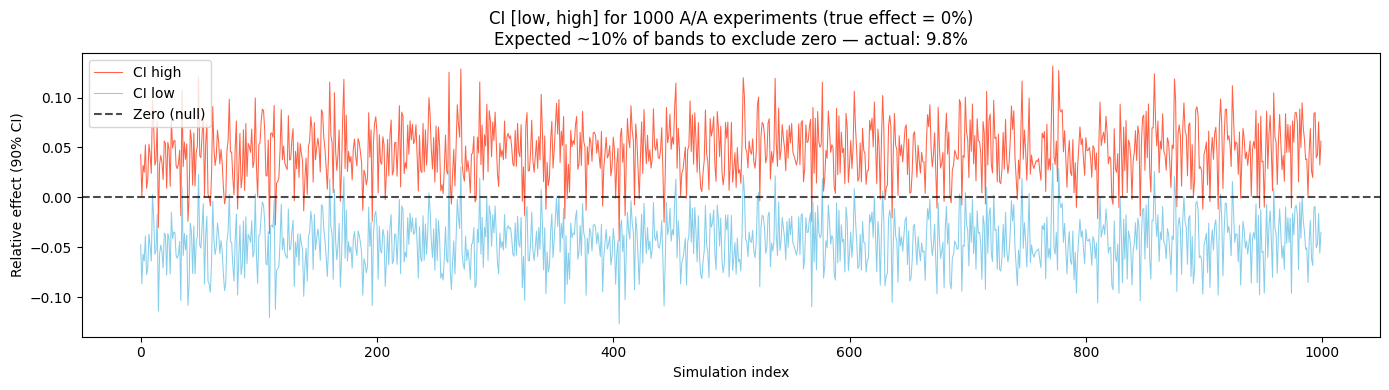

In [9]:
sim_stats['index'] = range(len(sim_stats))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sim_stats['index'], sim_stats['ci_h'], color='tomato',  alpha=1, lw=0.75, label='CI high')
ax.plot(sim_stats['index'], sim_stats['ci_l'], color='skyblue', alpha=1, lw=0.75, label='CI low')
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Zero (null)')
ax.set_xlabel('Simulation index')
ax.set_ylabel('Relative effect (90% CI)')
ax.set_title(f'CI [low, high] for {RANGE} A/A experiments (true effect = 0%)\n'
             f'Expected ~{ALPHA:.0%} of bands to exclude zero — actual: {((sim_stats.ci_l>=0)|(sim_stats.ci_h<=0)).mean():.1%}')
ax.legend()
plt.tight_layout()

# Summary & Takeaways

## What we found

| Metric | Result |
|--------|--------|
| Nominal α | 10% |
| Observed FP rate — no extension | ~10% ✓ calibrated |
| Fraction of experiments that "trend" | ~5–7% |
| FP rate *among* extended (trending) experiments | **materially above 10%** |

### The calibration check passes

The A/A simulation confirms that the two-sided z-test is well-calibrated: without any optional stopping, roughly 10% of experiments are falsely flagged as significant. The test machinery is working correctly.

### Optional stopping inflates Type I error

When we condition on extending only "trending" experiments, the false positive rate among that subset climbs significantly above α. The mechanism:

1. A trending result is one where random noise has already pushed the estimate positive.
2. The second batch of data is unbiased, but the *selection rule* (extend only if trending) means the pooled sample is biased upward.
3. Even a modest positive bias from the first batch, combined with the additional power from doubling N, is enough to push a meaningful fraction of these experiments over the significance threshold.

**In plain terms:** if you only extend experiments that look promising, you are not doing a neutral experiment — you are amplifying a lucky draw.

---

## Recommended practices

| Approach | Description |
|----------|-------------|
| **Pre-register the sample size** | Decide N before launch; analyse once at the end. |
| **Sequential / alpha-spending methods** | O'Brien-Fleming or Pocock boundaries let you peek at planned interim points without inflating α. |
| **Always-valid inference** | Methods based on e-values or mixture sequential probability ratio tests are valid at *any* stopping time. |
| **Bayesian A/B testing** | Posterior probabilities are coherent under continuous monitoring, but you still need a pre-specified decision rule. |

> **The core principle**: the stopping rule must be decided *before* looking at the data. Reacting to what you see — even by extending rather than stopping early — breaks the frequentist guarantees that the nominal α is supposed to provide.